# **Task 1**

**Loading Libraries**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Loading  and Displaying X Ray Image**

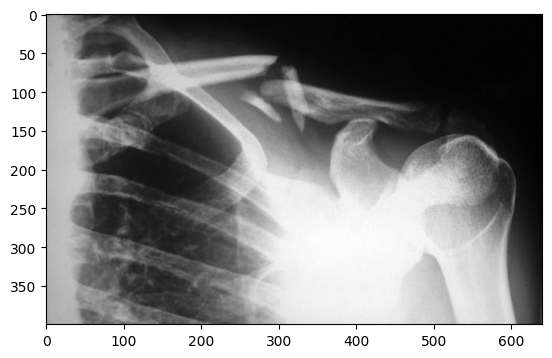

In [ ]:
img=cv2.imread('/content/img1.jpg',0)
plt.imshow(img,cmap='gray')
plt.show()

**Contrast Enhancement**

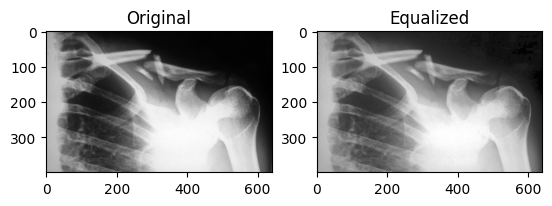

In [ ]:
equal=cv2.equalizeHist(img)
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Original')
plt.subplot(1,2,2)
plt.imshow(equal,cmap='gray')
plt.title('Equalized')
plt.show()

After applying histogram equalization to enchance contrast, we can see details better and and there is improved bone structure definition.

**Color Mapping**

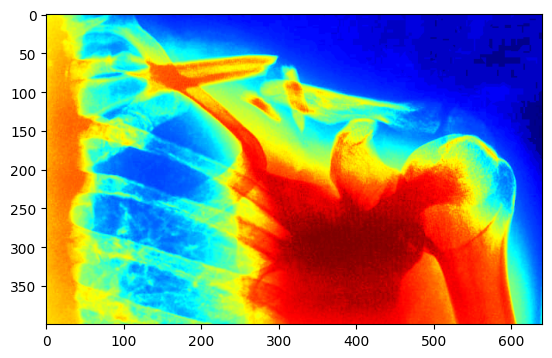

In [ ]:
heat=cv2.applyColorMap(equal,cv2.COLORMAP_JET)
plt.imshow(cv2.cvtColor(heat,cv2.COLOR_BGR2RGB))
plt.show()

**Color Balancing**

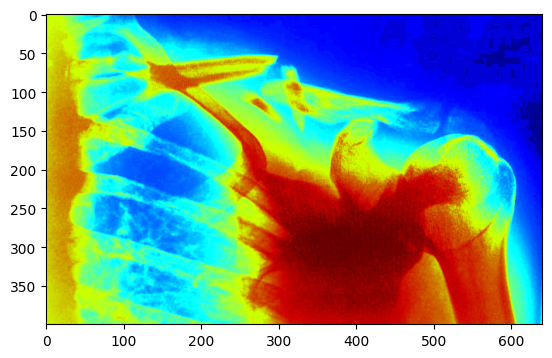

In [ ]:
b=1.1
g=1.1
r=0.8
adj=np.clip(heat*[b,g,r],0,255).astype(np.uint8)
plt.imshow(cv2.cvtColor(adj,cv2.COLOR_BGR2RGB))
plt.show()

**Color Filtering**

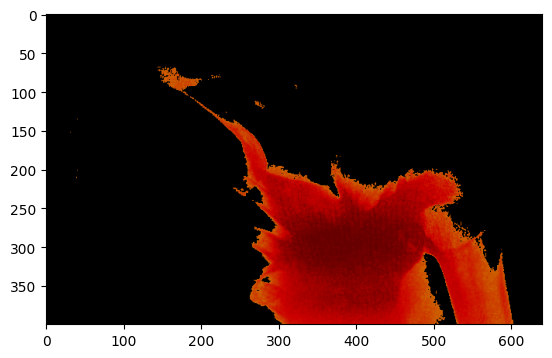

In [ ]:
low=np.array([0,0,100])
high=np.array([100,100,255])
mask=cv2.inRange(adj,low,high)
fil=cv2.bitwise_and(adj,adj,mask=mask)
plt.imshow(cv2.cvtColor(fil,cv2.COLOR_BGR2RGB))
plt.show()

**Logarithmic Transformation**

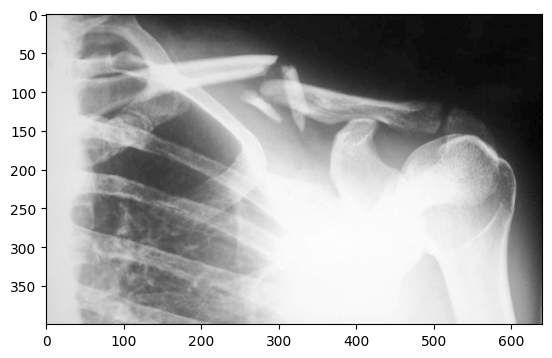

In [ ]:
c=255/(np.log(1+np.max(img)))
log=(c*np.log(1+img)).astype(np.uint8)
plt.imshow(log,cmap='gray')
plt.show()

**Power Law Transformation**

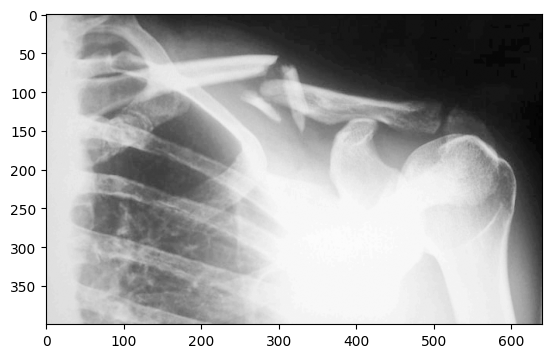

In [ ]:
g=0.5
pow=np.power(log,g)
pow=np.clip(pow*(255/np.max(pow)),0,255).astype(np.uint8)
plt.imshow(pow,cmap='gray')
plt.show()

# **TASK 2**

**Loading Libraries**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Loading Modalities**

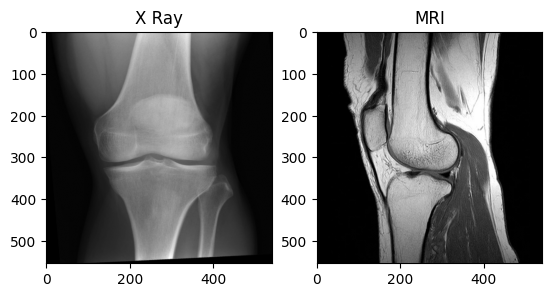

In [ ]:
x=cv2.imread('/content/xray.jpg',0)
m=cv2.imread('/content/mri.jpg',0)
x=cv2.resize(x,(m.shape[1],m.shape[0]))
plt.subplot(1,2,1)
plt.imshow(x,cmap='gray')
plt.title('X Ray')
plt.subplot(1,2,2)
plt.imshow(m,cmap='gray')
plt.title('MRI')
plt.show()

**Histogram Equalization**

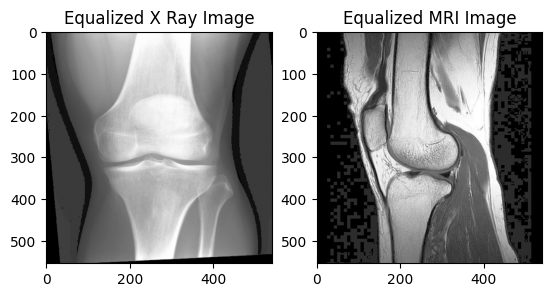

In [ ]:
xeq=cv2.equalizeHist(x)
meq=cv2.equalizeHist(m)
plt.subplot(1,2,1)
plt.imshow(xeq,cmap='gray')
plt.title('Equalized X Ray Image')
plt.subplot(1,2,2)
plt.imshow(meq,cmap='gray')
plt.title('Equalized MRI Image')
plt.show()

**Color Mapping and Fusion**

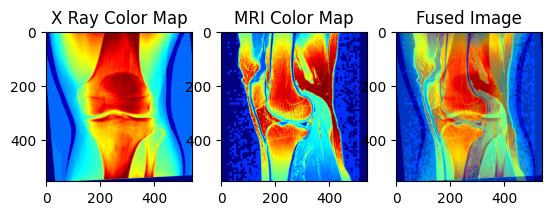

In [ ]:
xh=cv2.applyColorMap(xeq,cv2.COLORMAP_JET)
mh=cv2.applyColorMap(meq,cv2.COLORMAP_JET)
fuse=cv2.addWeighted(xh,0.5,mh,0.5,0)
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(xh,cv2.COLOR_BGR2RGB))
plt.title('X Ray Color Map')
plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(mh,cv2.COLOR_BGR2RGB))
plt.title('MRI Color Map')
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(fuse,cv2.COLOR_BGR2RGB))
plt.title('Fused Image')
plt.show()

**Weighted Fusion**

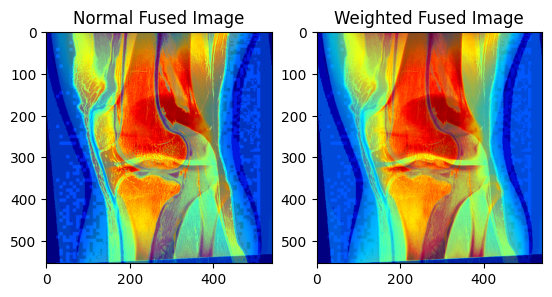

In [ ]:
wfuse=cv2.addWeighted(xh,0.7,mh,0.3,0)
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(fuse,cv2.COLOR_BGR2RGB))
plt.title('Normal Fused Image')
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(wfuse,cv2.COLOR_BGR2RGB))
plt.title('Weighted Fused Image')
plt.show()

**Logarithmic and Power Law Transformations**

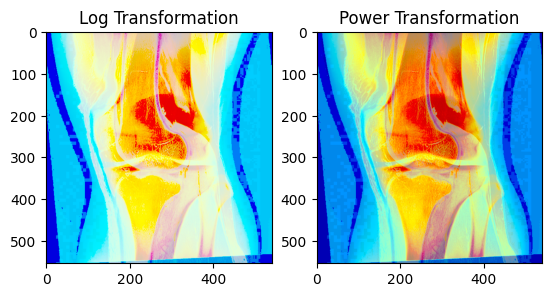

In [ ]:
f=wfuse.astype(np.float32)
c=255/(np.log(1+np.max(f)))
log=(c*np.log(1+f)).astype(np.uint8)
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(log,cv2.COLOR_BGR2RGB))
plt.title('Log Transformation')
g=0.5
pow=np.power(f,g)
pow=np.clip(pow*(255/np.max(pow)),0,255).astype(np.uint8)
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(pow,cv2.COLOR_BGR2RGB))
plt.title('Power Transformation')
plt.show()

**Comparitive Analysis**

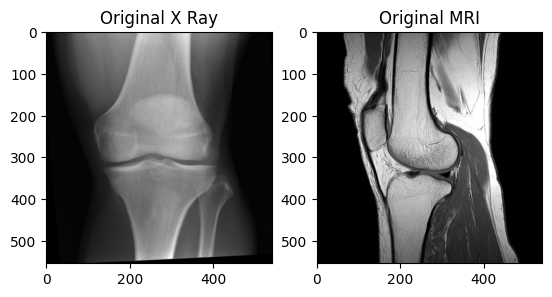

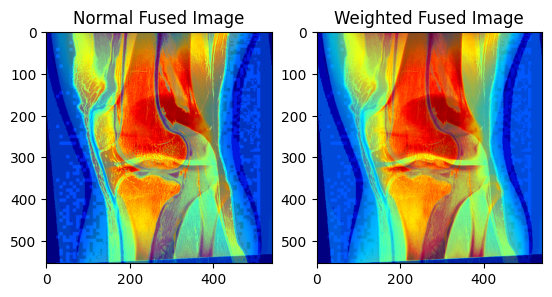

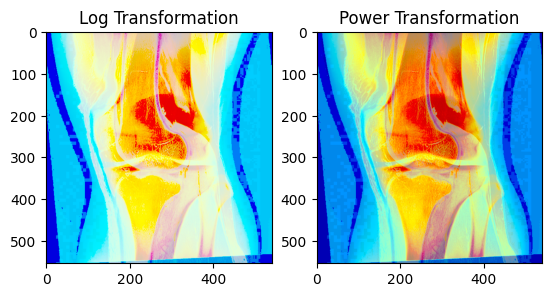

In [ ]:
x=cv2.resize(x,(m.shape[1],m.shape[0]))
plt.subplot(1,2,1)
plt.imshow(x,cmap='gray')
plt.title('Original X Ray')
plt.subplot(1,2,2)
plt.imshow(m,cmap='gray')
plt.title('Original MRI')
plt.show()
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(fuse,cv2.COLOR_BGR2RGB))
plt.title('Normal Fused Image')
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(wfuse,cv2.COLOR_BGR2RGB))
plt.title('Weighted Fused Image')
plt.show()
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(log,cv2.COLOR_BGR2RGB))
plt.title('Log Transformation')
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(pow,cv2.COLOR_BGR2RGB))
plt.title('Power Transformation')
plt.show()

Fusing X Ray and MRI images provides a comprehensive view of both skeletal structures and soft tissue in a single image. It enhances contrast and highlights subtle anatomical details that may be missed when using one modality. This improves diagnostic precision, supports better detection of abnormalities, and helps in accurate treatment planning. By integrating structural and functional information, the fusion approach ensures more reliable and complete clinical assessments.